# 02 · Resultados — Pronóstico de demanda para reposición inteligente

Este notebook es el **resumen ejecutivo** del proyecto: qué se construyó, qué evidencia de los datos motivó cada decisión, y cómo interpretar los resultados del modelo. No contiene lógica de negocio: todo el trabajo pesado vive en el pipeline (`src/`) y aquí solo se **leen los artefactos** que éste produce.

## Qué se construyó

Un pipeline de pronóstico de demanda a **14 días** para las **480 series tienda × categoría**, con tres etapas ejecutables:

| Comando | Qué hace | Artefactos |
|---|---|---|
| `uv run retail-backtest` | Valida los modelos contra baselines con walk-forward (6 cortes) | `outputs/backtests/<run>/` |
| `uv run retail-train` | Entrena el modelo final con toda la historia y lo serializa | `outputs/models/<run>/` |
| `uv run retail-predict` | Pronostica los próximos 14 días con el último modelo | `outputs/forecasts/<run>/` |

**Los cuatro competidores del backtest** (predicen exactamente las mismas celdas):

- `gradient_boosting_prior` — **el sistema propuesto**: `HistGradientBoostingRegressor` global (pérdida Poisson, rezagos ≥ 14 días, calendario, atributos de tienda) **+ prior de eventos** desde fuentes públicas (INEGI EMEC, ANTAD, BBVA Research), aplicado como **complemento en inferencia** — el factor externo solo completa la escala que el modelo no detecta por sí mismo — con **disciplina de vintage**: para pronosticar una fecha del año *Y* solo se usan factores publicados antes de *Y* (tabla versionada en `data/external/event_priors.csv`).
- `gradient_boosting` — el mismo modelo **sin** prior (ablación: aísla cuánto aporta el prior).
- `sistema_actual` — la señal del sistema de reposición vigente reescalada a unidades. Ventaja informacional: usa la señal emitida *el mismo día* que pronostica.
- `naive_estacional` — promedio del mismo día de la semana, 2–4 semanas atrás. El piso a vencer.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, viz
from src.seguimiento.artifacts import latest_run_dir
from src.preprocesamiento.data import load_calendar, load_stores, load_transactions
from src.evaluacion.metrics import evaluate

warnings.filterwarnings("ignore")
viz.apply_style()

tx, stores, cal = load_transactions(), load_stores(), load_calendar()

run_dir = latest_run_dir("backtests")
preds = pd.read_csv(run_dir / "predictions.csv", parse_dates=["date"])
metrics = pd.read_csv(run_dir / "metrics.csv")
print(f"Backtest leído de: {run_dir}")
print(f"{len(preds):,} predicciones | modelos: {sorted(preds.modelo.unique())}")

# Estética fija de los actores en todo el notebook
MODEL_COLORS = {
    "real": viz.INK,
    "gradient_boosting_prior": "#2a78d6",
    "gradient_boosting": "#4a3aa7",
    "sistema_actual": "#e34948",
    "naive_estacional": "#eda100",
}
MODEL_LABELS = {
    "gradient_boosting_prior": "Modelo propuesto (GB + prior de eventos)",
    "gradient_boosting": "GB sin prior (ablación)",
    "sistema_actual": "Sistema actual",
    "naive_estacional": "Naïve estacional",
}
ORDEN = ["gradient_boosting_prior", "gradient_boosting", "sistema_actual", "naive_estacional"]

# Solo celdas con real observado: todos los modelos se comparan sobre lo mismo
scored = preds[preds.y_true.notna()].merge(stores[["store_id", "store_format"]], on="store_id")

Backtest leído de: /Users/owner/Downloads/Prueba_Tecnica_DS/outputs/backtests/20260706_125751
161,280 predicciones | modelos: ['gradient_boosting', 'gradient_boosting_prior', 'naive_estacional', 'sistema_actual']


---
## 1 · Los datos detrás de cada decisión de diseño

### 1.1 El calendario mueve la demanda (y es conocido de antemano)

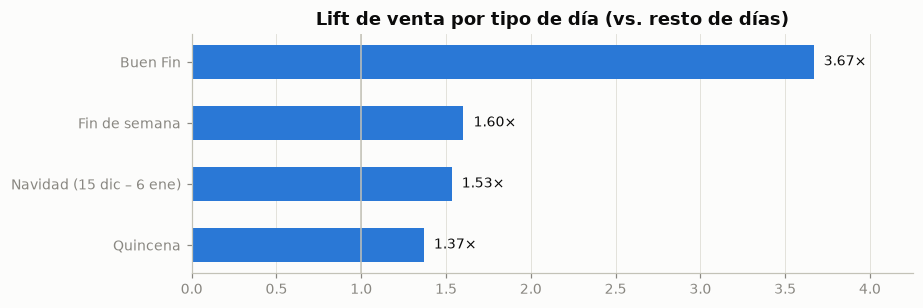

In [2]:
txc = tx.merge(cal, on="date")

def lift(mask):
    return txc[mask].amount_total.mean() / txc[~mask].amount_total.mean()

lifts = pd.Series({
    "Buen Fin": lift(txc.is_buen_fin),
    "Fin de semana": lift(txc.is_weekend),
    "Navidad (15 dic – 6 ene)": lift(txc.is_navidad_season),
    "Quincena": lift(txc.is_payday),
}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 2.9))
bars = ax.barh(lifts.index, lifts.values, color=viz.ACCENT, height=0.55)
ax.axvline(1, color=viz.BASELINE, lw=1)
for b, v in zip(bars, lifts.values):
    ax.text(v + 0.06, b.get_y() + b.get_height() / 2, f"{v:.2f}×",
            va="center", fontsize=9, color=viz.INK)
ax.set_xlim(0, lifts.max() * 1.16)
ax.set_title("Lift de venta por tipo de día (vs. resto de días)")
ax.grid(axis="y", visible=False)
plt.tight_layout()

> **Decisión →** los flags del calendario (día de semana, quincena, eventos) entran como *features* del día objetivo: son los drivers más fuertes de la demanda y se conocen con anticipación ilimitada.

### 1.2 El sistema de reposición actual reacciona en lugar de anticipar

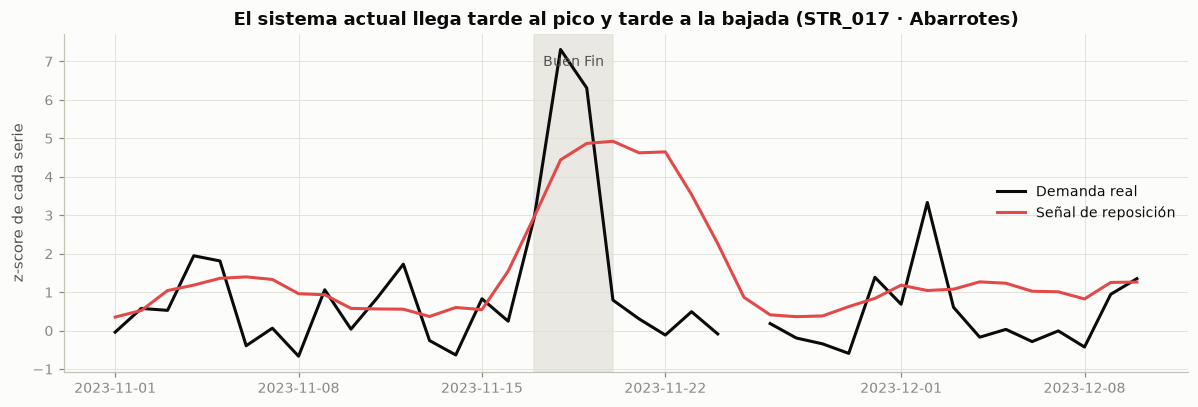

In [3]:
txs = tx.sort_values(["store_id", "category", "date"]).reset_index(drop=True)
g = txs.groupby(["store_id", "category"], observed=True)
txs["units_z"] = (txs.units_sold - g.units_sold.transform("mean")) / g.units_sold.transform("std")
txs["rs_z"] = (txs.replenishment_signal - g.replenishment_signal.transform("mean")) \
              / g.replenishment_signal.transform("std")

s = txs[(txs.store_id == "STR_017") & (txs.category == "Abarrotes")]
win = s[(s.date >= "2023-11-01") & (s.date <= "2023-12-10")]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axvspan(pd.Timestamp("2023-11-17"), pd.Timestamp("2023-11-20"),
           color=viz.GRID, alpha=0.7, zorder=0)
ax.plot(win.date, win.units_z, color=MODEL_COLORS["real"], lw=2, label="Demanda real")
ax.plot(win.date, win.rs_z, color=MODEL_COLORS["sistema_actual"], label="Señal de reposición")
ax.text(pd.Timestamp("2023-11-18 12:00"), ax.get_ylim()[1] * 0.93, "Buen Fin",
        ha="center", va="top", fontsize=9, color=viz.INK_SECONDARY)
ax.legend(loc="center right")
ax.set_title("El sistema actual llega tarde al pico y tarde a la bajada (STR_017 · Abarrotes)")
ax.set_ylabel("z-score de cada serie")
plt.tight_layout()

> **Decisión →** la señal del sistema actual es ~una media móvil de la demanda pasada: sub-surte ~34% durante el pico y sobre-surte ~2.3× después. Por eso el producto es un **pronóstico predictivo**, la señal queda **excluida como feature** (sería fuga de información: se deriva de la demanda) y se usa como **baseline a vencer**.

### 1.3 Las tiendas son muy heterogéneas

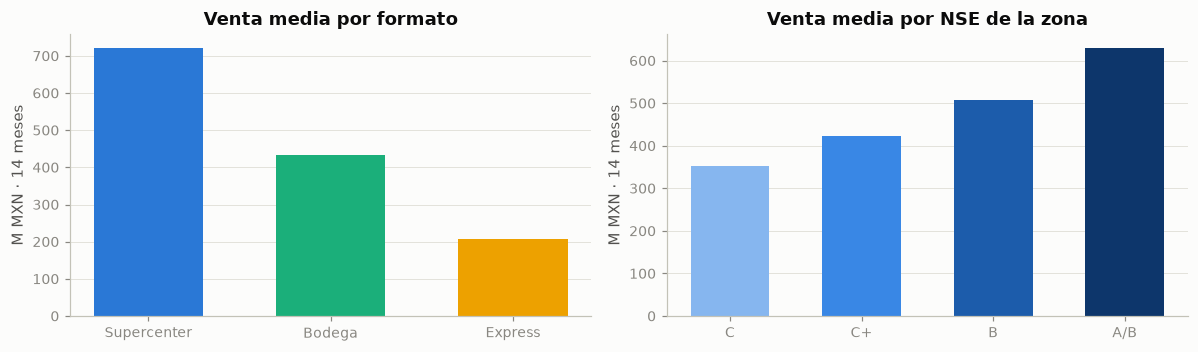

Dispersión: la tienda más grande vende 7.5× lo de la menor


In [4]:
rev = tx.groupby("store_id").amount_total.sum().rename("rev")
stx = stores.merge(rev, on="store_id")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
f = stx.groupby("store_format", observed=True).rev.mean() / 1e6
axes[0].bar(f.index.astype(str), f.values, width=0.6,
            color=[viz.FORMAT_COLORS[x] for x in f.index])
axes[0].set_title("Venta media por formato")
axes[0].set_ylabel("M MXN · 14 meses")

nse = stx.groupby("socioeconomic_level", observed=True).rev.mean() / 1e6
axes[1].bar(nse.index.astype(str), nse.values, width=0.6, color=viz.ORDINAL_STEPS)
axes[1].set_title("Venta media por NSE de la zona")
axes[1].set_ylabel("M MXN · 14 meses")
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(f"Dispersión: la tienda más grande vende {stx.rev.max() / stx.rev.min():.1f}× lo de la menor")

> **Decisión →** un **modelo global** (uno para las 480 series, no 480 modelos): aprende los patrones compartidos una sola vez y los ajusta por serie con los atributos de tienda (formato, tamaño, NSE, región) y los rezagos propios de cada serie.

### 1.4 El evento más importante del año no existe en la historia de entrenamiento

La historia empieza en enero 2023: el Buen Fin que hay que pronosticar es **el primero que el modelo ve en su vida**. Ningún algoritmo aprende un evento con cero ejemplos — y un modelo de árboles ni siquiera puede *extrapolar* a magnitudes que nunca vio en el target.

> **Decisión →** inyectar **priors de eventos desde fuentes públicas** (INEGI EMEC, ANTAD, BBVA Research: ediciones 2018–2022 del Buen Fin) como **complemento del modelo, no como multiplicador ciego**: en cada día de evento se mide cuánto efecto ya detecta el modelo por sí solo — su predicción normal vs. la contrafactual con los flags del evento apagados — y el factor externo solo completa la escala faltante: `final = contrafactual × max(implícito, externo)` en picos, y `× min(implícito, externo)` cuando el prior es de **supresión** (factor < 1). El prior tiene además **perfil diario** dentro de la temporada navideña: Nochebuena, 25 de diciembre y Fin de Año como picos (~2.5–3×), y 1 de enero (0.5) más "cuesta de enero" (0.8) como supresión — la temporada no es un bloque plano. La regla anti-leakage es de **vintage** — para fechas del año *Y* solo se usan factores publicados antes de *Y* — verificada por prueba automática (`tests/test_priors.py`). Lo observado en 2023 queda versionado como prior legítimo para 2024.

Y la regla que gobierna todo el diseño de features: **ningún dato de demanda posterior a t − 14** entra al pronóstico del día *t* (rezagos de 14/21/28 días, múltiplos de 7). Cada predicción del backtest es un pronóstico *honesto* emitido 14 días antes (`tests/test_features.py`).

---
## 2 · Resultados del backtest

**Cómo leer las métricas:** `WAPE` = error total como fracción de las unidades reales (0.25 → "me equivoco 25 de cada 100 unidades"; menor es mejor y es la métrica que decide). `MAE` = unidades de error promedio por tienda-categoría-día. `bias` = signo del error neto: negativo → sub-pronóstico (quiebre de stock), positivo → sobre-pronóstico (merma). Compara siempre **modelos dentro del mismo segmento**, nunca segmentos entre sí.

**Incertidumbre:** cada WAPE lleva su **IC 95%** por *bootstrap de bloques de fecha* — se remuestrean días completos, no filas sueltas, porque los errores de las 480 series se mueven juntos dentro de un mismo día y remuestrear filas daría intervalos irrealmente estrechos. Y la prueba formal de "A le gana a B" no es comparar dos intervalos: es el **ΔWAPE pareado** (mismos días remuestreados para ambos modelos, la dificultad común se cancela); si su IC no cruza 0, la ventaja es significativa.

WAPE por segmento y modelo:
          gradient_boosting_prior  gradient_boosting  sistema_actual  naive_estacional
segmento                                                                              
total                       0.275              0.326           0.325             0.416
pico                        0.316              0.459           0.369             0.519
normal                      0.253              0.253           0.301             0.360 

Sesgo por segmento y modelo (− = sub-pronóstico / quiebre, + = sobre / merma):
          gradient_boosting_prior  gradient_boosting  sistema_actual  naive_estacional
segmento                                                                              
total                       0.035             -0.135          -0.068            -0.093
pico                        0.087             -0.390          -0.231            -0.387
normal                      0.006              0.006           0.022             0.070 

WAPE con IC 95% (bo

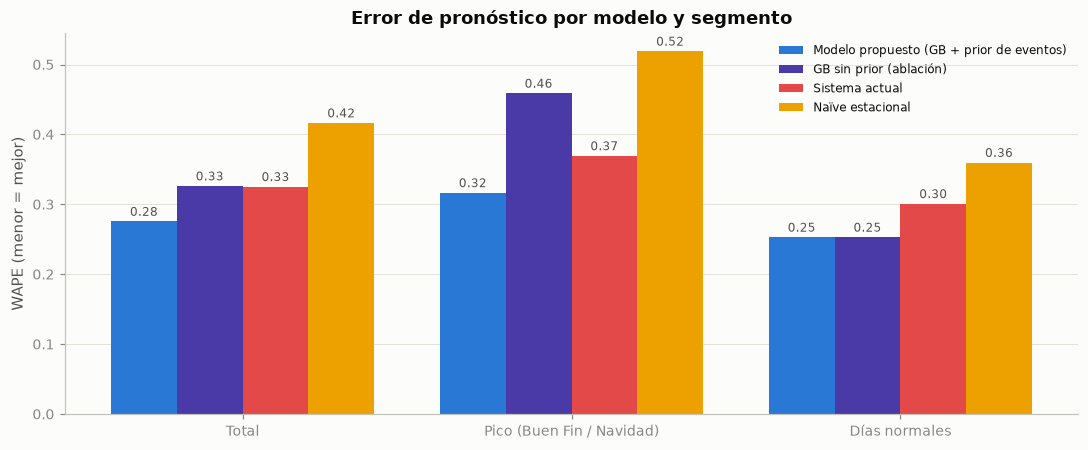

In [5]:
tabla = metrics.pivot(index="segmento", columns="modelo", values="wape") \
               .loc[["total", "pico", "normal"], ORDEN]
tabla.columns.name = None
print("WAPE por segmento y modelo:")
print(tabla.round(3).to_string(), "\n")

sesgo = metrics.pivot(index="segmento", columns="modelo", values="bias") \
               .loc[["total", "pico", "normal"], ORDEN]
sesgo.columns.name = None
print("Sesgo por segmento y modelo (− = sub-pronóstico / quiebre, + = sobre / merma):")
print(sesgo.round(3).to_string(), "\n")

ic = metrics.assign(wape_ic=[f"{r.wape:.3f} [{r.wape_lo:.3f}, {r.wape_hi:.3f}]"
                             for r in metrics.itertuples()]) \
            .pivot(index="segmento", columns="modelo", values="wape_ic") \
            .loc[["total", "pico", "normal"], ORDEN]
ic.columns.name = None
print("WAPE con IC 95% (bootstrap por bloques de fecha):")
print(ic.to_string(), "\n")

paired = pd.read_csv(run_dir / "paired_diffs.csv")
print("ΔWAPE pareado — campeón vs. cada rival (negativo = campeón mejor;")
print("significativo si el IC no cruza 0):")
print(paired.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(3)
ancho = 0.2
for i, modelo in enumerate(ORDEN):
    barras = ax.bar(x + (i - 1.5) * ancho, tabla[modelo], ancho,
                    color=MODEL_COLORS[modelo], label=MODEL_LABELS[modelo])
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{b.get_height():.2f}", ha="center", fontsize=8, color=viz.INK_SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(["Total", "Pico (Buen Fin / Navidad)", "Días normales"])
ax.set_ylabel("WAPE (menor = mejor)")
ax.set_title("Error de pronóstico por modelo y segmento")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="x", visible=False)
plt.tight_layout()

In [6]:
por_fold = evaluate(scored, by=["fold_origin", "modelo"]) \
    .pivot(index="fold_origin", columns="modelo", values="wape")[ORDEN].round(3)
por_fold.columns.name = None
etiquetas = {"2023-07-03": "jul (normal)", "2023-09-04": "sep (normal)",
             "2023-11-06": "nov — BUEN FIN", "2023-12-11": "dic — NAVIDAD",
             "2024-01-15": "ene (normal)", "2024-02-12": "feb (normal)"}
por_fold.index = [etiquetas[i] for i in por_fold.index]
print("WAPE por corte del walk-forward (gana el menor por fila):")
por_fold

WAPE por corte del walk-forward (gana el menor por fila):


,gradient_boosting_prior,gradient_boosting,sistema_actual,naive_estacional
jul (normal),0.236,0.236,0.311,0.268
sep (normal),0.258,0.258,0.301,0.284
nov — BUEN FIN,0.278,0.450,0.368,0.508
dic — NAVIDAD,0.320,0.350,0.333,0.400
ene (normal),0.274,0.274,0.293,0.743
feb (normal),0.241,0.241,0.291,0.270


In [7]:
# El evento nunca visto, en detalle: solo los 4 días del Buen Fin
bf = scored[(scored.segmento == "pico") & (scored.fold_origin == "2023-11-06")]
detalle = evaluate(bf, by=["modelo"]).set_index("modelo").loc[ORDEN, ["wape", "bias"]].round(3)
detalle.index = [MODEL_LABELS[m] for m in detalle.index]
print("Días del Buen Fin 2023 (evento con CERO ejemplos en entrenamiento):")
detalle

Días del Buen Fin 2023 (evento con CERO ejemplos en entrenamiento):


,wape,bias
Modelo propuesto (GB + prior de eventos),0.293,-0.117
GB sin prior (ablación),0.603,-0.603
Sistema actual,0.417,-0.343
Naïve estacional,0.681,-0.681


**Lectura de los resultados:**

1. **En días normales el modelo gana siempre** (WAPE 0.253 vs 0.301 del sistema actual, −5 pp) con sesgo < 1%. El prior es **neutro por diseño** fuera de eventos: ambas variantes comparten el mismo modelo y sus predicciones son idénticas ahí.
2. **El prior de eventos convierte la derrota en victoria… sin hacer trampa.** En el Buen Fin — evento con *cero* ejemplos de entrenamiento — el modelo sin prior sub-pronostica 60% (sesgo −0.603). Con priors construidos solo con información pública **anterior a 2023**, el sesgo cae a **−0.117** y el WAPE del fold baja de 0.450 a **0.278: le gana incluso al sistema actual (0.368), que ve la señal del mismo día**. El residuo de −12% es la firma de honestidad: el prior legítimo (ANTAD ~2×) se queda corto frente al 3.7× real de esta cadena — y ese 3.7× ya quedó versionado como prior para 2024.
3. **El perfil diario del prior rescató los días más valiosos de diciembre:** con un factor plano por temporada, Nochebuena quedaba en −46% y el 25 en −36%; con el perfil diario quedan en **+8% y +6%**, y el fold de Navidad (0.320) también le gana al sistema actual (0.333). **El modelo propuesto gana los 6 folds contra los 3 competidores.**
4. En el agregado, el **modelo propuesto es el mejor sistema global** (WAPE 0.275 vs 0.325 del sistema actual; en picos 0.316 vs 0.369) con sesgo pico de +0.09.
5. **Significancia (ΔWAPE pareado):** la ventaja sobre el sistema actual es significativa en el total (−0.050, IC [−0.081, −0.020]) y en días normales (−0.048, IC [−0.063, −0.034]); sobre el naïve, significativa en todos los segmentos. En **picos**, la ventaja puntual sobre el sistema actual (−0.053) **no alcanza significancia** con solo 15 días de evento en el año (IC [−0.127, +0.038]) — se necesita más historia de eventos para confirmarla. Lo que sí es significativo en picos es el **aporte del prior** vs. la ablación sin prior (−0.142, IC [−0.239, −0.014]).
6. El residuo conocido: los días *ordinarios* del 15–23 de diciembre sobre-pronostican ~+30%. La causa ya no es el prior: las **medias móviles del modelo quedan contaminadas por el Buen Fin** (que cae dentro de su ventana de 28 días) e inflan la base sobre la que se aplica el factor. Refinamiento siguiente: calcular las ventanas móviles excluyendo días de evento.
7. El fold de enero sigue mostrando la falla del enfoque reactivo: el naïve arrastra el pico navideño (0.743); el modelo pasa limpio (0.274).

---
## 3 · Las predicciones vistas en sus agrupaciones

Cada gráfica agrega las celdas evaluadas: línea negra = demanda real; colores = lo que cada modelo pronosticó **14 días antes**. Se grafican el sistema propuesto y los dos baselines (la ablación sin prior vive en las tablas). Solo hay valores en las 6 ventanas de prueba del walk-forward — los huecos entre ventanas son esperados.

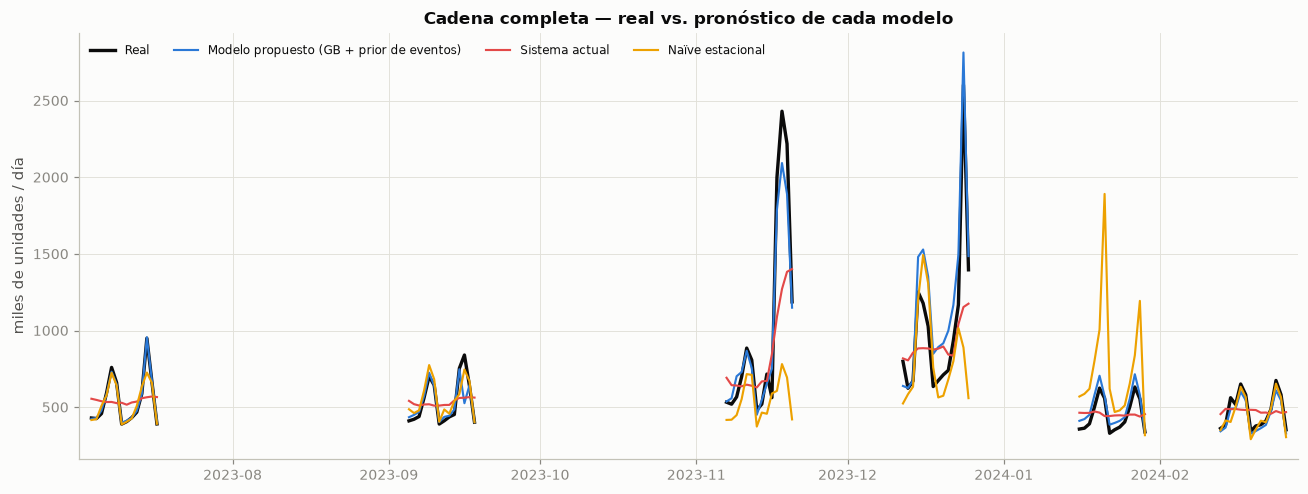

In [8]:
FECHAS = pd.date_range(scored.date.min(), scored.date.max(), freq="D")
EN_GRAFICAS = ["gradient_boosting_prior", "sistema_actual", "naive_estacional"]

def plot_real_vs_modelos(ax, df, titulo, unidades="miles de unidades / día"):
    real = df[df.modelo == "gradient_boosting_prior"].groupby("date").y_true.sum() / 1e3
    ax.plot(real.reindex(FECHAS).index, real.reindex(FECHAS).values,
            color=MODEL_COLORS["real"], lw=2.2, label="Real")
    for modelo in EN_GRAFICAS:
        serie = df[df.modelo == modelo].groupby("date").y_pred.sum() / 1e3
        ax.plot(serie.reindex(FECHAS).index, serie.reindex(FECHAS).values,
                color=MODEL_COLORS[modelo], lw=1.4, label=MODEL_LABELS[modelo])
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(unidades)
    ax.margins(x=0.01)

fig, ax = plt.subplots(figsize=(12, 4.6))
plot_real_vs_modelos(ax, scored, "Cadena completa — real vs. pronóstico de cada modelo")
ax.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()

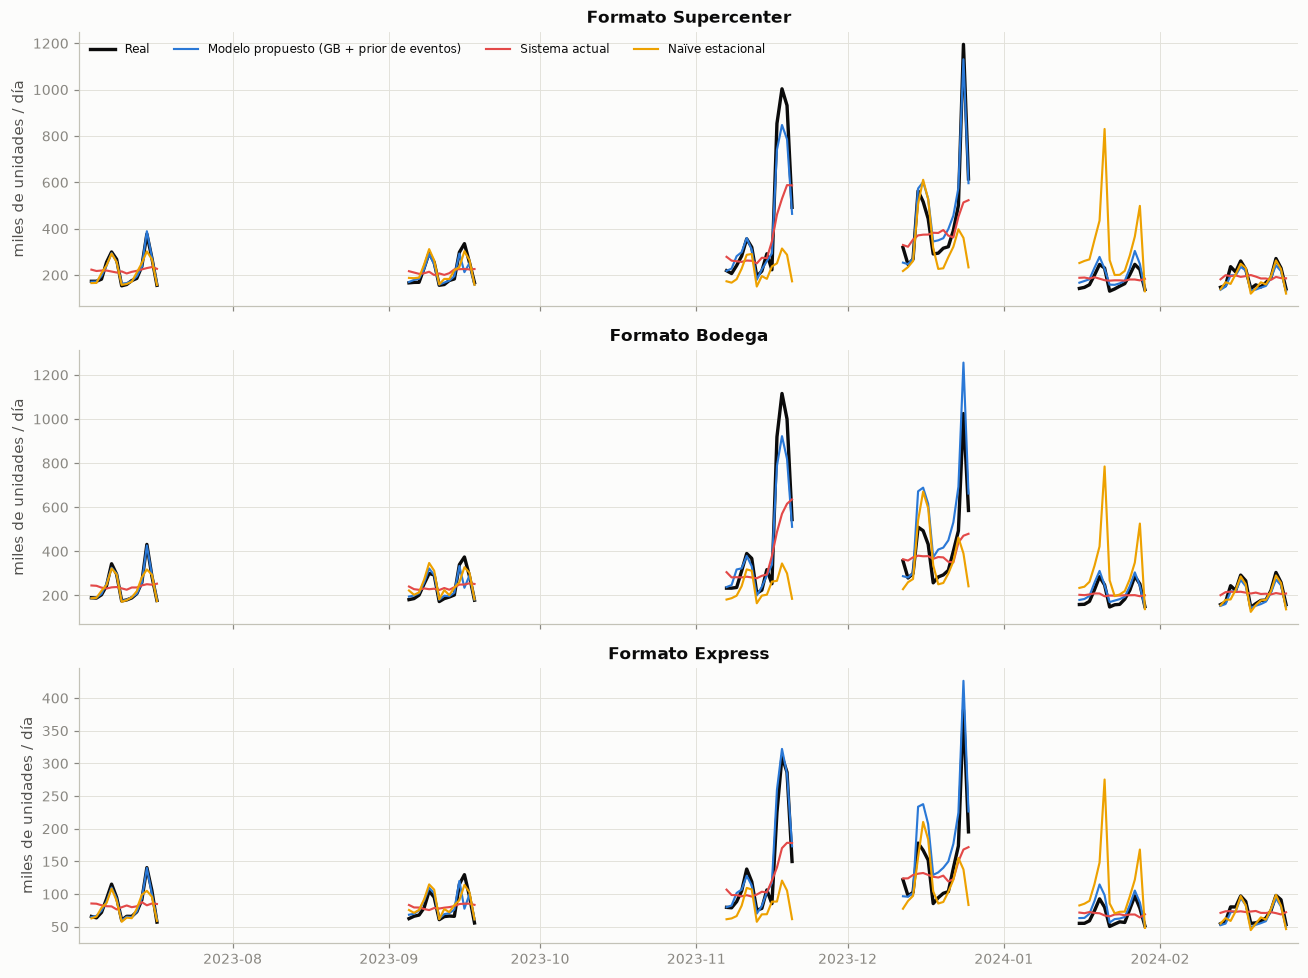

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, fmt in zip(axes, config.STORE_FORMATS):
    plot_real_vs_modelos(ax, scored[scored.store_format == fmt], f"Formato {fmt}")
axes[0].legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()

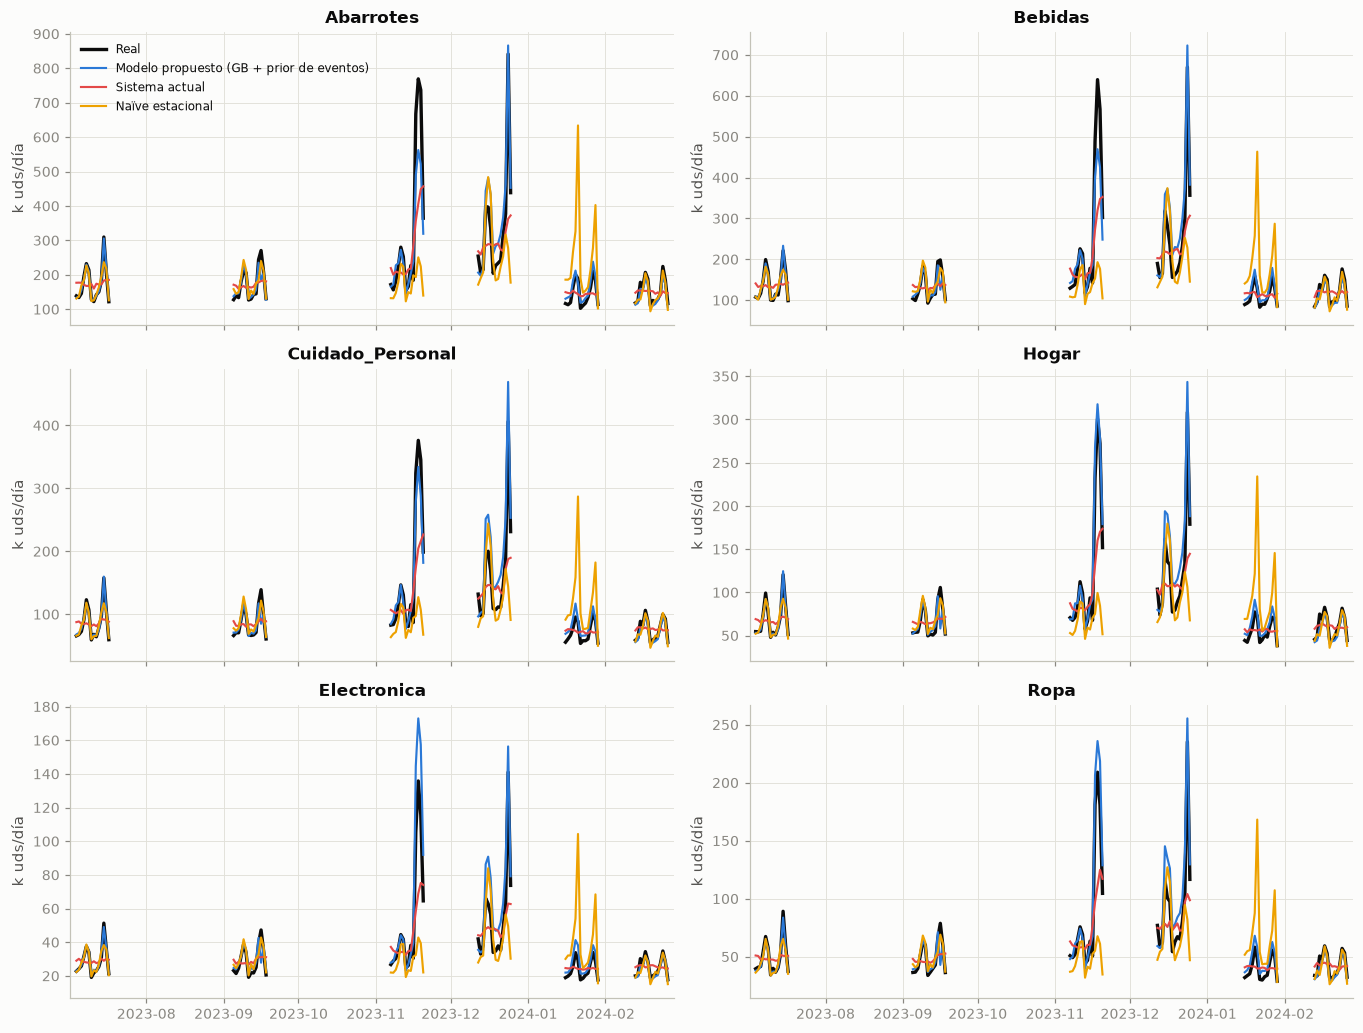

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12.5, 9.5), sharex=True)
for ax, cat in zip(axes.ravel(), config.CATEGORIES):
    plot_real_vs_modelos(ax, scored[scored.category == cat], cat, unidades="k uds/día")
axes[0, 0].legend(loc="upper left", fontsize=8)
plt.tight_layout()

### 3.1 ¿Y en números? WAPE por formato y por categoría

Se calcula sobre **días normales**: es la comparación justa de lo desplegable en el día a día (en picos, ver la sección 2).

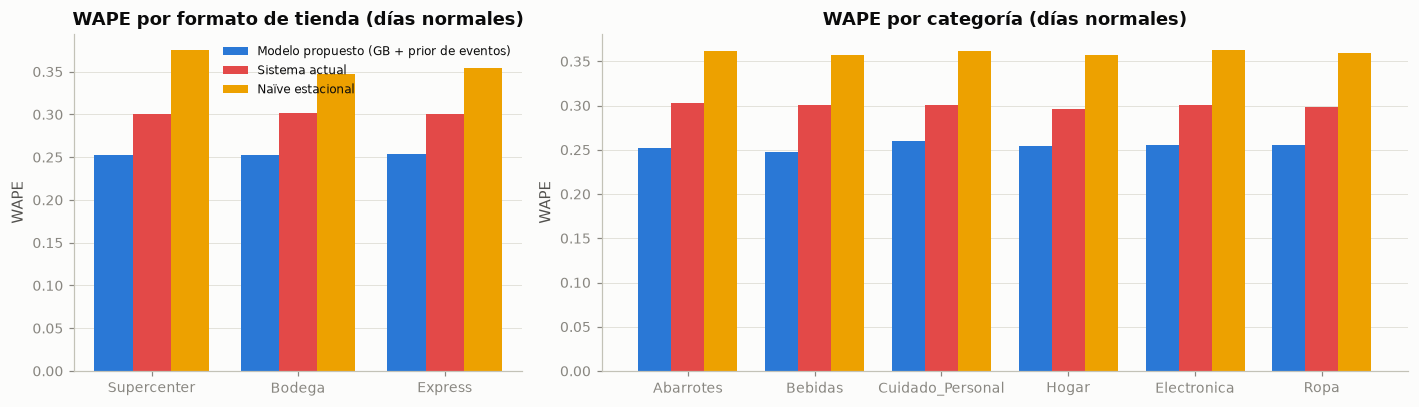

WAPE por formato (días normales):
modelo        gradient_boosting_prior  sistema_actual  naive_estacional
store_format                                                           
Supercenter                     0.252           0.300             0.375
Bodega                          0.253           0.301             0.348
Express                         0.254           0.301             0.354 

WAPE por categoría (días normales):
modelo            gradient_boosting_prior  sistema_actual  naive_estacional
category                                                                   
Abarrotes                           0.252           0.303             0.361
Bebidas                             0.247           0.301             0.357
Cuidado_Personal                    0.260           0.301             0.362
Hogar                               0.254           0.296             0.358
Electronica                         0.255           0.301             0.363
Ropa                                

In [11]:
def barras_wape(ax, tabla, titulo):
    x = np.arange(len(tabla))
    ancho = 0.26
    for i, modelo in enumerate(tabla.columns):
        ax.bar(x + (i - 1) * ancho, tabla[modelo], ancho,
               color=MODEL_COLORS[modelo], label=MODEL_LABELS[modelo])
    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, fontsize=9)
    ax.set_ylabel("WAPE")
    ax.set_title(titulo)
    ax.grid(axis="x", visible=False)

normales = scored[scored.segmento == "normal"]
por_formato = evaluate(normales, by=["modelo", "store_format"]) \
    .pivot(index="store_format", columns="modelo", values="wape") \
    .loc[config.STORE_FORMATS, EN_GRAFICAS]
por_categoria = evaluate(normales, by=["modelo", "category"]) \
    .pivot(index="category", columns="modelo", values="wape") \
    .loc[config.CATEGORIES, EN_GRAFICAS]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.8]})
barras_wape(axes[0], por_formato, "WAPE por formato de tienda (días normales)")
barras_wape(axes[1], por_categoria, "WAPE por categoría (días normales)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("WAPE por formato (días normales):")
print(por_formato.round(3).to_string(), "\n")
print("WAPE por categoría (días normales):")
print(por_categoria.round(3).to_string())

---
## 4 · Conclusiones

**Lo que el sistema propuesto (modelo + prior de eventos) ya hace mejor que el vigente:**

- **Días normales (85% del año):** WAPE 0.253 vs 0.301, sin sesgo (< 1%) — menos quiebres y menos merma a la vez, decidido **14 días antes** y no el mismo día. La mejora es uniforme en los 3 formatos y las 6 categorías.
- **Buen Fin — el examen más difícil:** pronosticando un evento con **cero ejemplos en su historia**, y usando únicamente información pública anterior a 2023 (INEGI/ANTAD/BBVA con regla de vintage), el sesgo pasa de −60% a **−12%** y el modelo gana el fold completo (0.278) incluso contra el sistema actual con su ventaja de información del mismo día (0.368).
- **Navidad con perfil diario:** Nochebuena y 25 de diciembre pasan de sub-pronosticar −46%/−36% (prior plano) a **+8%/+6%**; el 1 de enero y la "cuesta de enero" usan priors de *supresión* (factor < 1). Fold: 0.320 vs 0.333 del sistema actual.
- **El modelo propuesto gana los 6 folds del walk-forward contra los 3 competidores** — normales y picos. Agregado: WAPE total **0.275 vs 0.325**; en picos **0.316 vs 0.369**. La ventaja es **estadísticamente significativa** (ΔWAPE pareado, IC 95%) en total y días normales; en picos es consistente pero no concluyente con un solo año de eventos (15 días).
- **Post-pico:** el modelo no sufre la "cruda" del sistema reactivo (enero: 0.274 vs 0.743 del naïve que arrastra la Navidad).

**Los límites, dichos claramente:**

- Los días ordinarios del 15–23 de diciembre sobre-pronostican ~+30%: las medias móviles del modelo quedan **contaminadas por el Buen Fin** (dentro de su ventana de 28 días) e inflan la base. Refinamiento siguiente: ventanas móviles que excluyan días de evento.
- Los factores externos son estimaciones gruesas de fuentes públicas; al acumular el **segundo año de historia propia**, el prior se recalibra con lo observado (ya versionado con vintage 2023 en `data/external/event_priors.csv`, incluido el perfil diario medido) y eventualmente el evento se vuelve aprendible por el modelo mismo.

**Traducción a negocio:** los 4 días del Buen Fin venden ~3.7× un día normal (~370 M MXN/día de cadena). Pasar de sub-surtir 34–60% a −8% en esos días es proteger decenas de millones de pesos de venta por evento, con decisiones tomadas con 14 días de anticipación logística — y con validación walk-forward reproducible (`uv run retail-backtest`) como evidencia.